## Tabular Network

## Check GPU

In [1]:
import subprocess, warnings, platform, os, psutil, gc, time
warnings.filterwarnings('ignore')
try:
    r = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                  '--format=csv,noheader'], capture_output=True, text=True)
    if r.returncode == 0:
        print('GPU:', r.stdout.strip())
    else:
        print('CPU')
except FileNotFoundError:
    print('CPU')

GPU: Tesla T4, 15360 MiB
Tesla T4, 15360 MiB


In [2]:
print(f'Python  : {platform.python_version()}')
print(f'CPU     : {os.cpu_count()} logical cores')
print(f'RAM     : {psutil.virtual_memory().total/1e9:.1f} GB total  |  '
      f'{psutil.virtual_memory().available/1e9:.1f} GB free')

Python  : 3.12.12
CPU     : 4 logical cores
RAM     : 33.7 GB total  |  32.2 GB free


## Install dependencies

In [3]:
%%capture
!pip install -q torch==2.3.0 --quiet
!pip install -q pytorch-tabnet scikit-learn==1.5.1 numpy==1.26.4 matplotlib seaborn joblib psutil --quiet

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import (f1_score, accuracy_score, confusion_matrix,
                              classification_report, roc_curve, auc,
                              precision_recall_curve, average_precision_score)
from sklearn.utils.class_weight import compute_class_weight

print(f'torch          : {torch.__version__}')
print(f'numpy          : {np.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')

torch          : 2.3.0+cu121
numpy          : 1.26.4
CUDA available : True


In [5]:
random_seed   = 42
artefacts_dir = '/kaggle/input/notebooks/hossamhamdyfakry/2-ids-preprocessing/artefacts'
plots_dir     = '/kaggle/working/plots_tabnet'
models_dir    = '/kaggle/working/models_tabnet'
os.makedirs(plots_dir,  exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

torch.manual_seed(random_seed)
np.random.seed(random_seed)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')

Device : cuda


## Load Artefacts

In [6]:
le                    = joblib.load(f'{artefacts_dir}/label_encoder.pkl')
class_weight_dict     = joblib.load(f'{artefacts_dir}/class_weights.pkl')
class_weight_att_dict = joblib.load(f'{artefacts_dir}/class_weights_att.pkl')

print('Label encoder classes:')
for code, name in enumerate(le.classes_):
    print(f'  {code} : {name}')

Label encoder classes:
  0 : Analysis
  1 : Backdoor
  2 : Benign
  3 : Bot
  4 : Brute Force
  5 : DDoS
  6 : DoS
  7 : Exploits
  8 : Fuzzers
  9 : Generic
  10 : Infilteration
  11 : Reconnaissance
  12 : Shellcode
  13 : Theft
  14 : Worms
  15 : injection
  16 : mitm
  17 : password
  18 : ransomware
  19 : scanning
  20 : xss


## Load Data

In [7]:
# full_dataset — Model 1 (binary) + Model 2 (full multiclass)
X_train       = np.load(f'{artefacts_dir}/X_train.npy').astype(np.float32)
X_val         = np.load(f'{artefacts_dir}/X_val.npy').astype(np.float32)
X_test        = np.load(f'{artefacts_dir}/X_test.npy').astype(np.float32)
y_train_bin   = np.load(f'{artefacts_dir}/y_train_bin.npy').astype(np.int64)
y_val_bin     = np.load(f'{artefacts_dir}/y_val_bin.npy').astype(np.int64)
y_test_bin    = np.load(f'{artefacts_dir}/y_test_bin.npy').astype(np.int64)
y_train_multi = np.load(f'{artefacts_dir}/y_train_multi.npy').astype(np.int64)
y_val_multi   = np.load(f'{artefacts_dir}/y_val_multi.npy').astype(np.int64)
y_test_multi  = np.load(f'{artefacts_dir}/y_test_multi.npy').astype(np.int64)


## Training Set Subsampling
# For the limitation in our computing resoucres
We subsampled the training set from 13.7M down to 5M rows by capping Benign, DDoS, and DoS at 1.2M each, scanning, Reconnaissance, and xss at 400K, while keeping all rare attack classes at 100%. Val and test sets are left untouched at their original 4.56M rows each.

In [8]:

SUBSAMPLE_CAPS = {
     2 : 1_200_000,   # Benign
     5 : 1_200_000,   # DDoS
     6 : 1_200_000,   # DoS
    11 :   400_000,   # Reconnaissance
    19 :   400_000,   # scanning
    20 :   400_000,   # xss

}



In [9]:
rng = np.random.default_rng(42)
keep_idx = []
for cls_code in np.unique(y_train_multi):
    idx = np.where(y_train_multi == cls_code)[0]
    cap = SUBSAMPLE_CAPS.get(int(cls_code), len(idx))   
    if len(idx) > cap:
        idx = rng.choice(idx, size=cap, replace=False)
    keep_idx.append(idx)

keep_idx = np.concatenate(keep_idx)
keep_idx.sort()   

X_train       = X_train[keep_idx]
y_train_bin   = y_train_bin[keep_idx]
y_train_multi = y_train_multi[keep_idx]

In [10]:
print(f'Train  (subsampled) : {X_train.shape}  dtype={X_train.dtype}')
print(f'Val                 : {X_val.shape}')
print(f'Test                : {X_test.shape}')
print()
print('Train class distribution after subsampling:')
unique, counts = np.unique(y_train_multi, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  class {u:2d} : {c:>10,}')
print(f'  TOTAL   : {len(y_train_multi):>10,}')

Train  (subsampled) : (5226255, 42)  dtype=float32
Val                 : (4564510, 42)
Test                : (4564510, 42)

Train class distribution after subsampling:
  class  0 :        227
  class  1 :      3,496
  class  2 :  1,200,000
  class  3 :     11,759
  class  4 :     24,497
  class  5 :  1,200,000
  class  6 :  1,200,000
  class  7 :      5,951
  class  8 :      4,151
  class  9 :      1,933
  class 10 :     22,939
  class 11 :    400,000
  class 12 :        229
  class 13 :        422
  class 14 :         61
  class 15 :    133,775
  class 16 :      1,486
  class 17 :    214,708
  class 18 :        621
  class 19 :    400,000
  class 20 :    400,000
  TOTAL   :  5,226,255


## Evaluation Function

In [11]:
def predict_in_chunks(model, X, chunk_size=131072):
    results = []
    for start in range(0, len(X), chunk_size):
        chunk = X[start : start + chunk_size]
        preds = model.predict(chunk)
        results.append(preds.flatten().astype(int))
    return np.concatenate(results)


In [12]:
def predict_proba_in_chunks(model, X, chunk_size=131072):
    results = []
    for start in range(0, len(X), chunk_size):
        chunk = X[start : start + chunk_size]
        proba = model.predict_proba(chunk)
        results.append(proba)
    return np.vstack(results)

In [13]:
def evaluate(model, X, y, label='', class_names=None):
    preds = predict_in_chunks(model, X)          
    if hasattr(preds, 'flatten'):
        preds = preds.flatten()
    preds = preds.astype(int)
    acc   = accuracy_score(y, preds)
    mf1   = f1_score(y, preds, average='macro')
    wf1   = f1_score(y, preds, average='weighted')
    print(f"\n{'='*50}")
    print(f'{label}')
    print(f'Accuracy         : {acc:.4f}')
    print(f'Macro-F1         : {mf1:.4f}')
    print(f'Weighted-F1      : {wf1:.4f}')
    print(f"{'='*50}")
    print(classification_report(y, preds,
                                 target_names=class_names,
                                 zero_division=0))
    return preds

## Weights for multiclass models

In [14]:
def make_sample_weights(y, weight_dict):
    return np.array([weight_dict[c] for c in y], dtype=np.float32)
# smoothing out the weights
log_smoothed_multi_dict = {
    cls: max(1.0, 1.0 + np.log(weight))
    for cls, weight in class_weight_dict.items()
}

log_smoothed_att_dict = {
    cls: max(1.0, 1.0 + np.log(weight))
    for cls, weight in class_weight_att_dict.items()
}

## Model 1 — Binary Classifier

In [15]:
TABNET_PARAMS = {
    'n_d'               : 16,
    'n_a'               : 16,
    'n_steps'           : 3,
    'gamma'             : 1.3,
    'n_shared'          : 2,
    'lambda_sparse'     : 1e-4,
    'momentum'          : 0.02,
    'mask_type'         : 'entmax',
    'optimizer_fn'      : torch.optim.Adam,
    'optimizer_params'  : {'lr': 2e-2, 'weight_decay': 1e-4},
    'device_name'       : device,
    'seed'              : random_seed,
    'verbose'           : 1,
}

FIT_PARAMS = {
    'max_epochs'        : 50,
    'patience'          : 5,
    'batch_size'        : 32768,
    'virtual_batch_size': 1024,
    'num_workers'       : 2,
    'drop_last'         : False,
    
}

In [16]:

tabnet_bin = TabNetClassifier(**TABNET_PARAMS)

tabnet_bin.fit(
    X_train, y_train_bin,
    eval_set    = [(X_val, y_val_bin)],
    eval_metric = ['auc'],
    weights     = 1,                  
    **FIT_PARAMS
)

tabnet_bin.save_model(f'{models_dir}/tabnet_binary')






epoch 0  | loss: 0.11097 | val_0_auc: 0.98593 |  0:00:42s
epoch 1  | loss: 0.06983 | val_0_auc: 0.99754 |  0:01:23s
epoch 2  | loss: 0.06937 | val_0_auc: 0.99816 |  0:02:05s
epoch 3  | loss: 0.0659  | val_0_auc: 0.99823 |  0:02:46s
epoch 4  | loss: 0.08215 | val_0_auc: 0.99807 |  0:03:27s
epoch 5  | loss: 0.06635 | val_0_auc: 0.99822 |  0:04:08s
epoch 6  | loss: 0.075   | val_0_auc: 0.99808 |  0:04:50s
epoch 7  | loss: 0.06488 | val_0_auc: 0.99803 |  0:05:31s
epoch 8  | loss: 0.07974 | val_0_auc: 0.99723 |  0:06:13s

Early stopping occurred at epoch 8 with best_epoch = 3 and best_val_0_auc = 0.99823
Successfully saved model at /kaggle/working/models_tabnet/tabnet_binary.zip


'/kaggle/working/models_tabnet/tabnet_binary.zip'

In [17]:
# Free training data before prediction
del X_train, y_train_bin
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Test model_1 performance on the test set

In [18]:
preds_bin = evaluate(tabnet_bin, X_test, y_test_bin,
                      label='Model 1 — Binary — Test Set',
                      class_names=['Benign', 'Attack'])


Model 1 — Binary — Test Set
Accuracy         : 0.9831
Macro-F1         : 0.9809
Weighted-F1      : 0.9831
              precision    recall  f1-score   support

      Benign       0.97      0.98      0.97   1493266
      Attack       0.99      0.98      0.99   3071244

    accuracy                           0.98   4564510
   macro avg       0.98      0.98      0.98   4564510
weighted avg       0.98      0.98      0.98   4564510



## Learning Curve

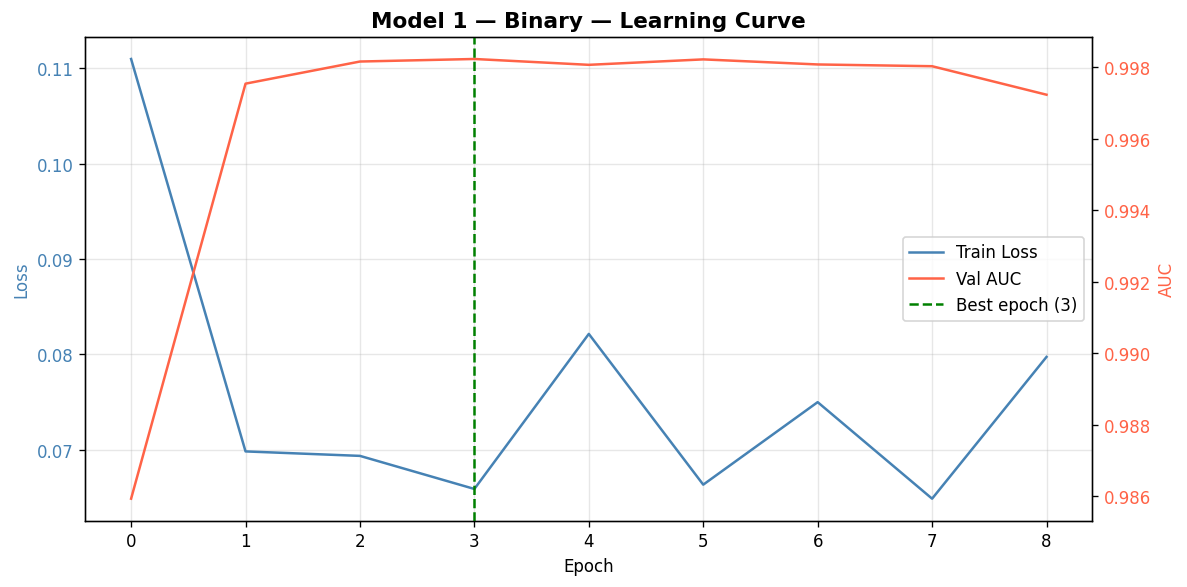

In [19]:
train_loss = tabnet_bin.history['loss']
val_auc    = tabnet_bin.history['val_0_auc']
best_epoch = np.argmax(val_auc)

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=120)

ax1.plot(train_loss, label='Train Loss', color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(val_auc, label='Val AUC', color='tomato')
ax2.axvline(best_epoch, color='green', linestyle='--',
            label=f'Best epoch ({best_epoch})')
ax2.set_ylabel('AUC', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

ax1.set_title('Model 1 — Binary — Learning Curve', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Confusion Matrix

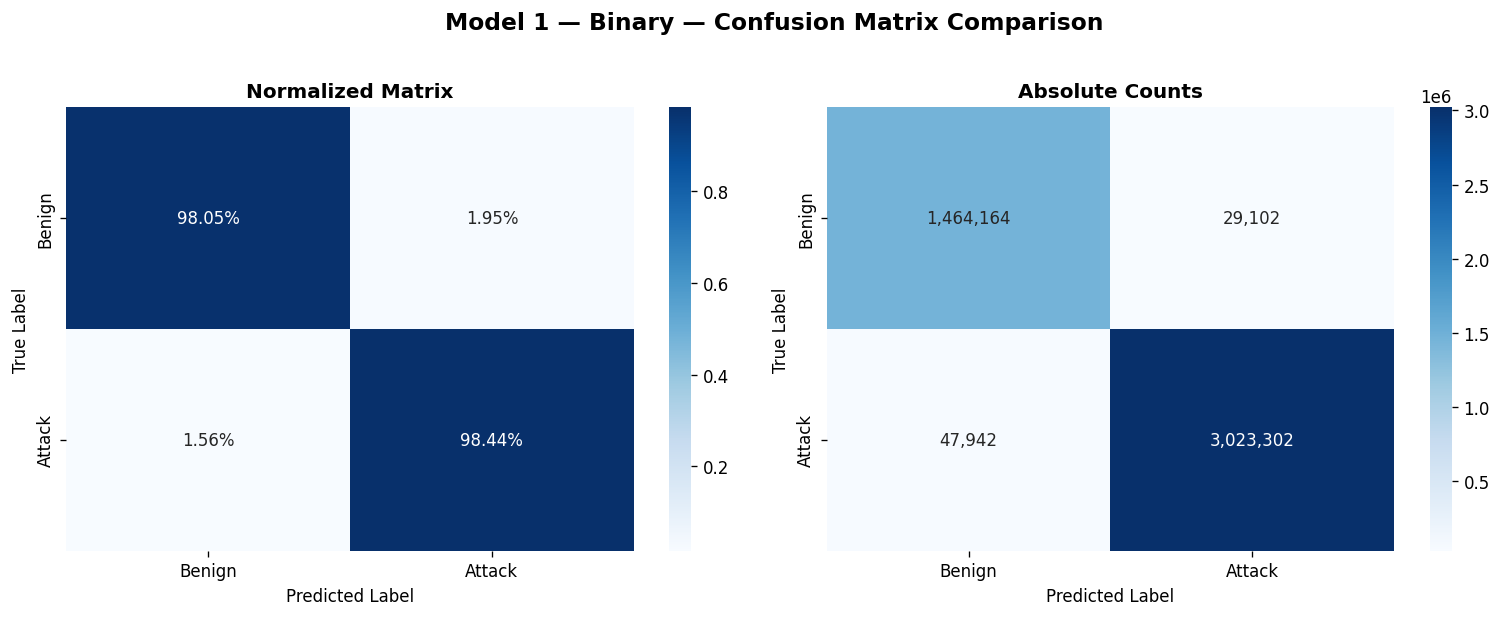

In [20]:
cm_norm = confusion_matrix(y_test_bin, preds_bin, normalize='true')
cm_raw  = confusion_matrix(y_test_bin, preds_bin)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120)
labels = ['Benign', 'Attack']


sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Normalized Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')


sns.heatmap(cm_raw, annot=True, fmt=',d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Absolute Counts', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

fig.suptitle('Model 1 — Binary — Confusion Matrix Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_confusion_matrix_side_by_side.png', dpi=120, bbox_inches='tight')
plt.show()

## ROC Curve

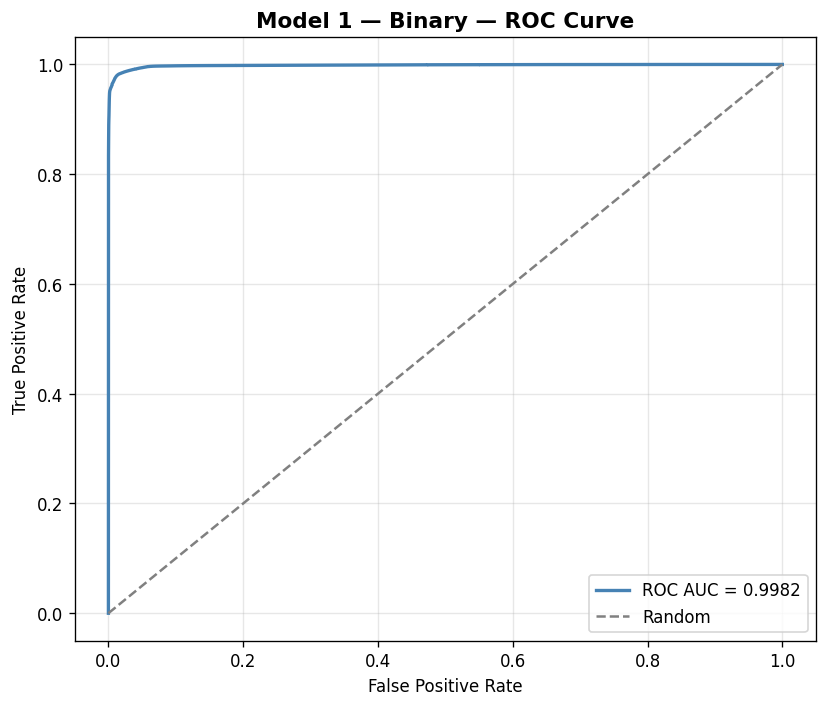

In [21]:
proba_bin   = predict_proba_in_chunks(tabnet_bin, X_test)[:, 1]  # chunked — avoids OOM
fpr, tpr, _ = roc_curve(y_test_bin, proba_bin)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
ax.set_title('Model 1 — Binary — ROC Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_roc.png', dpi=120, bbox_inches='tight')
plt.show()

##  Precision-Recall Curve

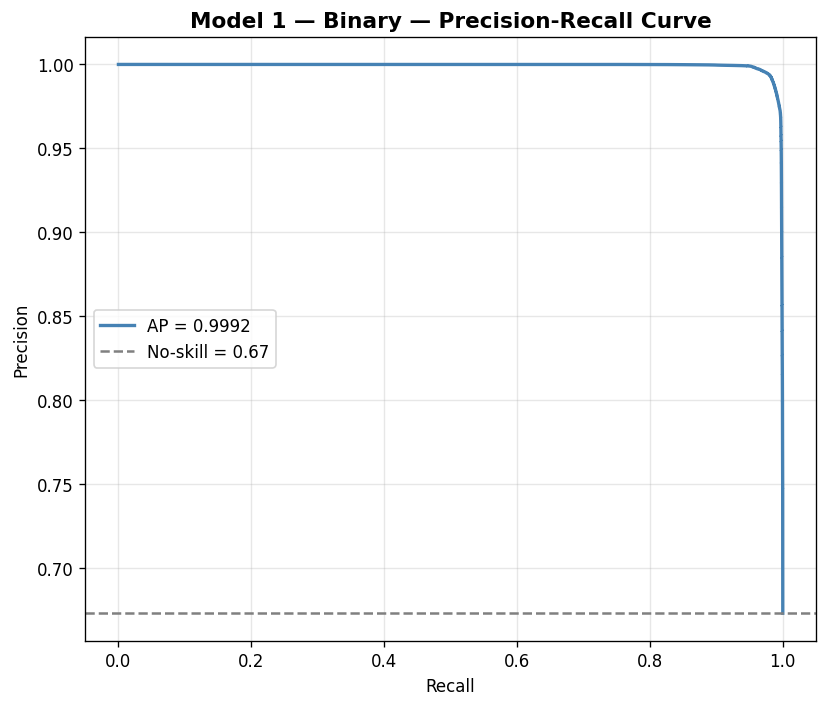

In [22]:
precision, recall, _ = precision_recall_curve(y_test_bin, proba_bin)
ap       = average_precision_score(y_test_bin, proba_bin)
no_skill = y_test_bin.mean()

fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
ax.plot(recall, precision, color='steelblue', lw=2, label=f'AP = {ap:.4f}')
ax.axhline(no_skill, color='gray', linestyle='--', label=f'No-skill = {no_skill:.2f}')
ax.set_title('Model 1 — Binary — Precision-Recall Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Feature Importance (TabNet attention masks)

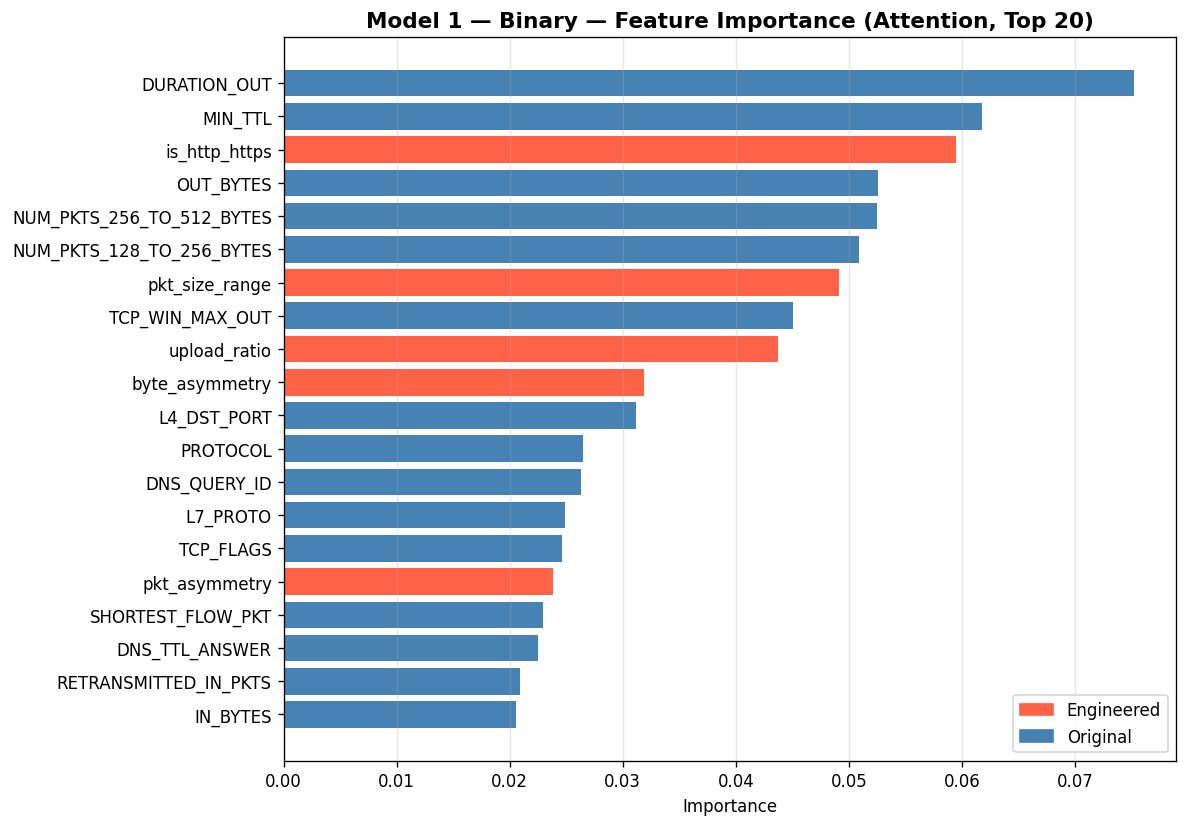

In [23]:
mi_cols    = joblib.load(f'{artefacts_dir}/mi_selected_cols.pkl')
engineered = {
    'bytes_per_pkt_in', 'bytes_per_pkt_out', 'upload_ratio',
    'byte_asymmetry', 'pkt_asymmetry', 'is_http_https',
    'is_ssh_telnet', 'is_dns', 'ttl_range', 'syn_only_flag',
    'pkt_size_range', 'retransmit_ratio', 'retransmit_pkt_ratio'
}

importance = tabnet_bin.feature_importances_
feat_df    = pd.DataFrame({'feature': mi_cols, 'importance': importance})
feat_df    = feat_df.sort_values('importance', ascending=False).head(20)
colors     = ['tomato' if f in engineered else 'steelblue'
               for f in feat_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_title('Model 1 — Binary — Feature Importance (Attention, Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
patches = [mpatches.Patch(color='tomato',    label='Engineered'),
           mpatches.Patch(color='steelblue', label='Original')]
ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [24]:
# Save preds to disk and free RAM
np.save(f'{models_dir}/preds_bin.npy', preds_bin)
del preds_bin
del tabnet_bin
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()



9311

## Model 2 
## Full Multiclass 

In [25]:
# Reload training data for Model 2 ,reapply same subsample mask
X_train       = np.load(f'{artefacts_dir}/X_train.npy').astype(np.float32)[keep_idx]
y_train_multi = np.load(f'{artefacts_dir}/y_train_multi.npy').astype(np.int64)[keep_idx]
print(f'Reloaded X_train for Model 2 : {X_train.shape}')

Reloaded X_train for Model 2 : (5226255, 42)


In [26]:
tabnet_multi = TabNetClassifier(**TABNET_PARAMS)

tabnet_multi.fit(
    X_train, y_train_multi,
    eval_set    = [(X_val, y_val_multi)],
    eval_metric = ['accuracy', 'balanced_accuracy'],
    weights     = make_sample_weights(y_train_multi, log_smoothed_multi_dict),
    **FIT_PARAMS
)
tabnet_multi.save_model(f'{models_dir}/tabnet_multiclass')





epoch 0  | loss: 0.46673 | val_0_accuracy: 0.91455 | val_0_balanced_accuracy: 0.50501 |  0:00:43s
epoch 1  | loss: 0.2534  | val_0_accuracy: 0.95225 | val_0_balanced_accuracy: 0.61502 |  0:01:27s
epoch 2  | loss: 0.22759 | val_0_accuracy: 0.95929 | val_0_balanced_accuracy: 0.69082 |  0:02:11s
epoch 3  | loss: 0.21772 | val_0_accuracy: 0.9612  | val_0_balanced_accuracy: 0.71987 |  0:02:55s
epoch 4  | loss: 0.23798 | val_0_accuracy: 0.93741 | val_0_balanced_accuracy: 0.60362 |  0:03:39s
epoch 5  | loss: 0.2376  | val_0_accuracy: 0.96071 | val_0_balanced_accuracy: 0.69528 |  0:04:22s
epoch 6  | loss: 0.24242 | val_0_accuracy: 0.95949 | val_0_balanced_accuracy: 0.68367 |  0:05:06s
epoch 7  | loss: 0.21397 | val_0_accuracy: 0.96073 | val_0_balanced_accuracy: 0.69227 |  0:05:50s
epoch 8  | loss: 0.21236 | val_0_accuracy: 0.95828 | val_0_balanced_accuracy: 0.72917 |  0:06:33s
epoch 9  | loss: 0.20675 | val_0_accuracy: 0.95899 | val_0_balanced_accuracy: 0.73411 |  0:07:17s
epoch 10 | loss: 0.2

'/kaggle/working/models_tabnet/tabnet_multiclass.zip'

In [27]:
# Free training data before prediction
del X_train, y_train_multi
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Test model_2 performance on the test set

In [28]:
preds_multi = evaluate(tabnet_multi, X_test, y_test_multi,
                        label='Model 2 — Full Multiclass — Test Set',
                        class_names=le.classes_)


Model 2 — Full Multiclass — Test Set
Accuracy         : 0.9615
Macro-F1         : 0.7283
Weighted-F1      : 0.9627
                precision    recall  f1-score   support

      Analysis       0.13      0.56      0.21        75
      Backdoor       0.98      0.92      0.95      1165
        Benign       0.99      0.94      0.97   1493266
           Bot       0.99      1.00      1.00      3920
   Brute Force       1.00      0.98      0.99      8165
          DDoS       0.99      0.98      0.99   1310954
           DoS       0.98      0.98      0.98   1088123
      Exploits       0.68      0.88      0.77      1984
       Fuzzers       0.62      0.89      0.73      1384
       Generic       0.89      0.73      0.80       645
 Infilteration       0.28      0.08      0.12      7646
Reconnaissance       0.67      0.92      0.78    166365
     Shellcode       0.66      0.86      0.75        76
         Theft       0.21      0.90      0.35       141
         Worms       1.00      0.24      0.

## Learning Curve

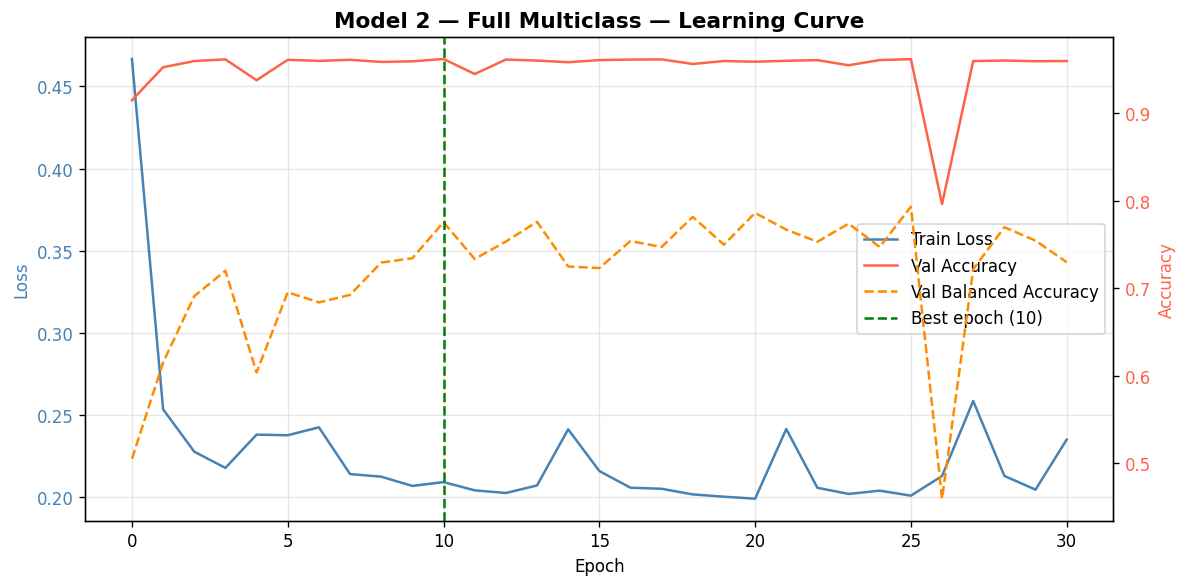

In [29]:
train_loss = tabnet_multi.history['loss']
val_acc    = tabnet_multi.history['val_0_accuracy']
val_bal    = tabnet_multi.history['val_0_balanced_accuracy']
best_epoch = np.argmax(val_acc)

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=120)

ax1.plot(train_loss, label='Train Loss', color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(val_acc, label='Val Accuracy',          color='tomato')
ax2.plot(val_bal, label='Val Balanced Accuracy', color='darkorange', linestyle='--')
ax2.axvline(best_epoch, color='green', linestyle='--',
            label=f'Best epoch ({best_epoch})')
ax2.set_ylabel('Accuracy', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

ax1.set_title('Model 2 — Full Multiclass — Learning Curve', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Confusion Matrix

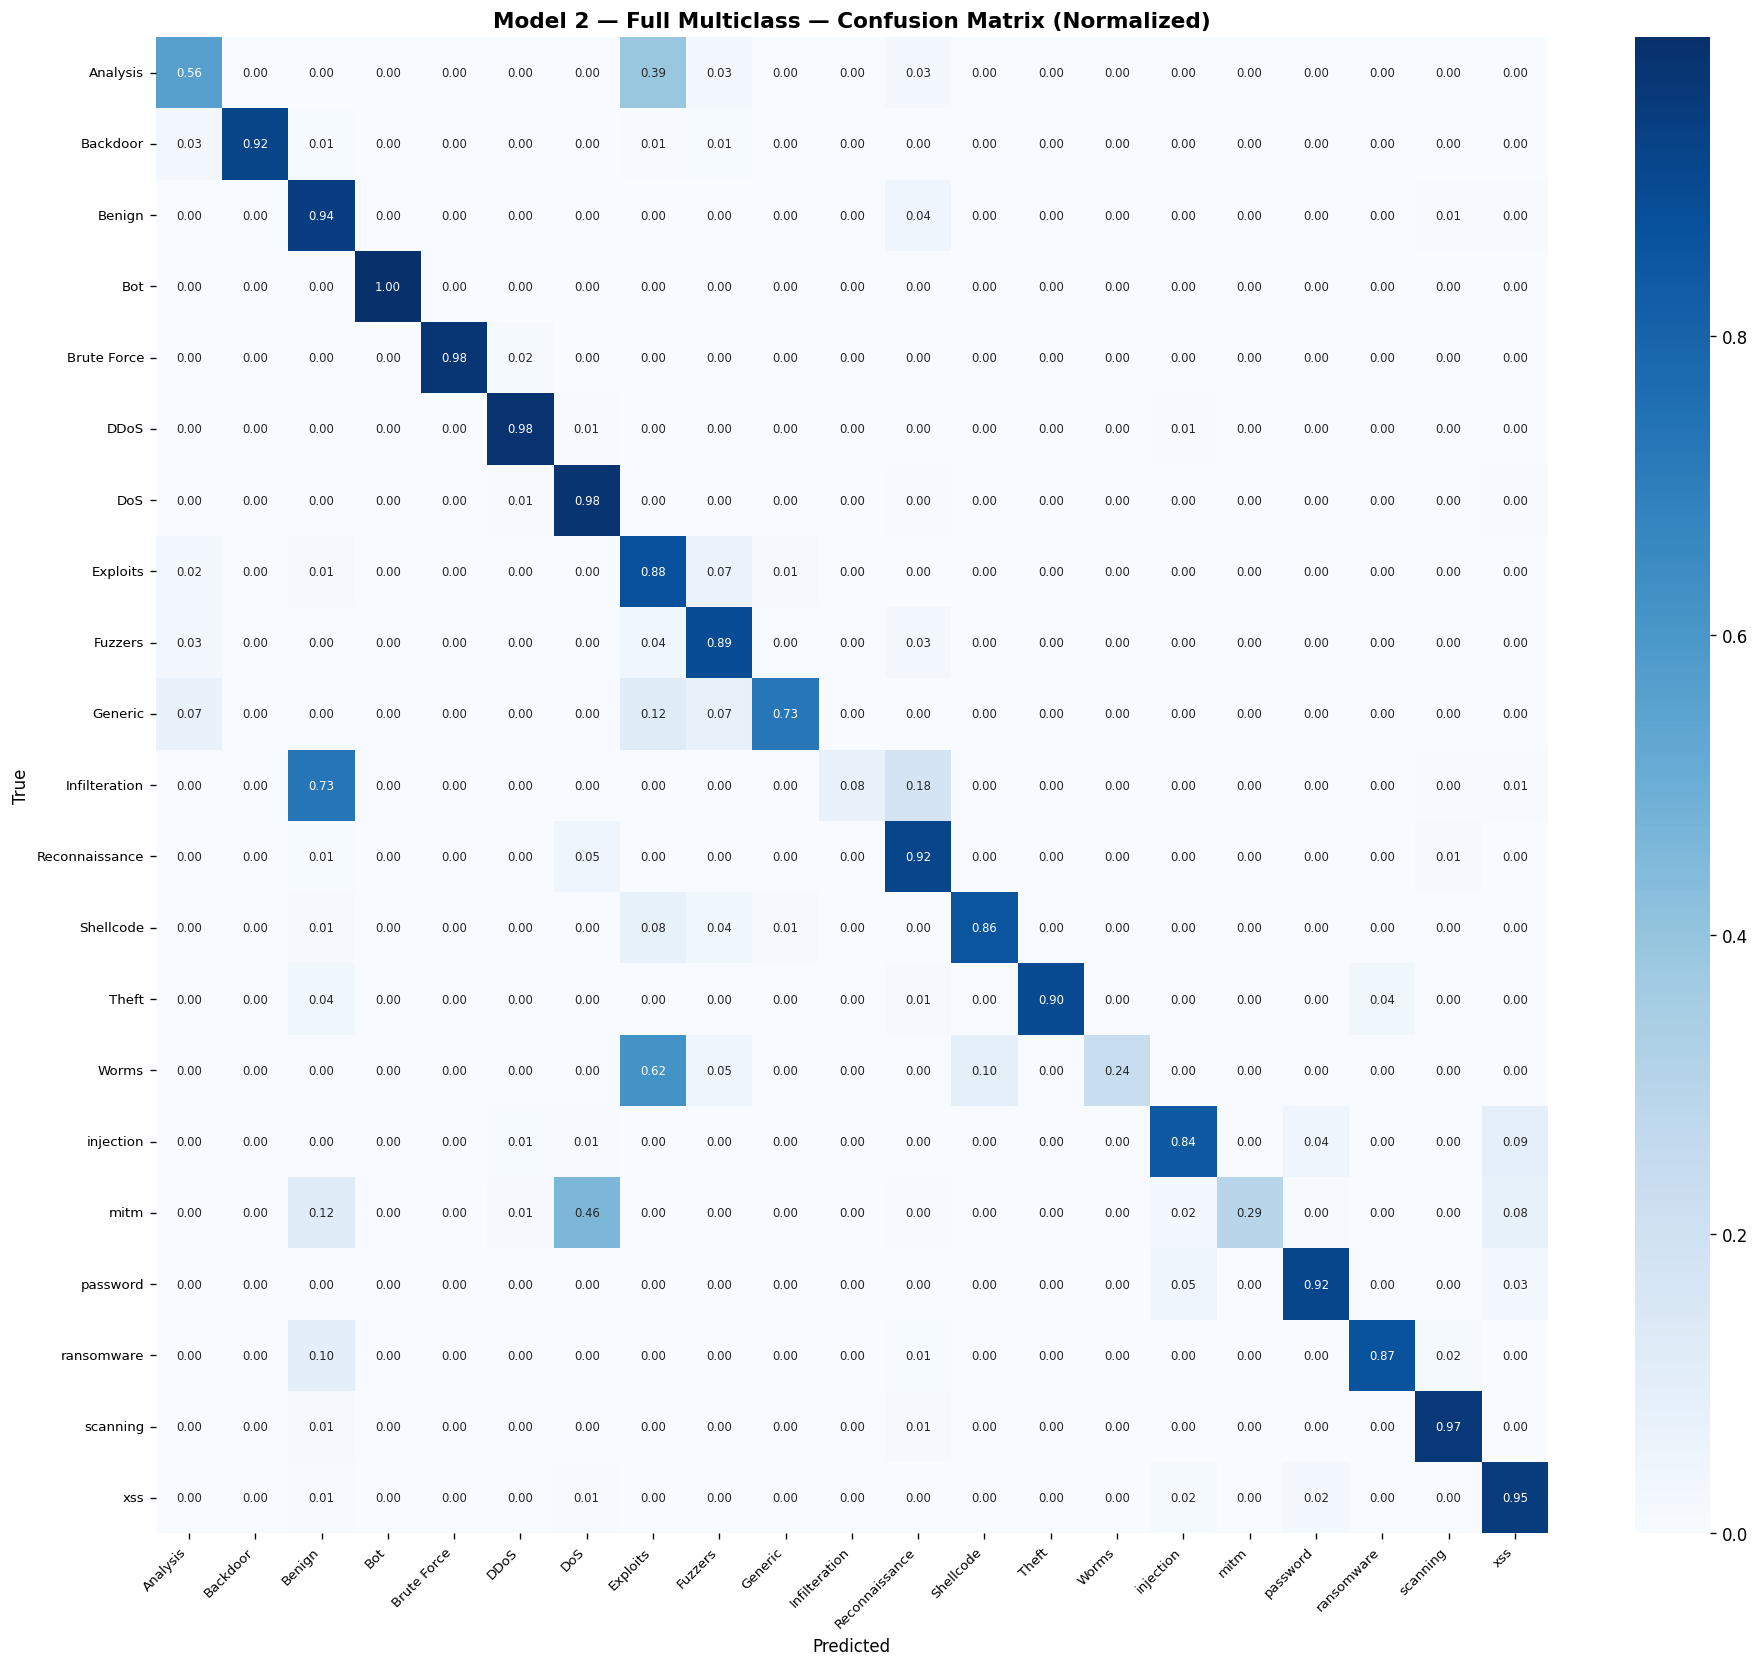

In [30]:

cm = confusion_matrix(y_test_multi, preds_multi, normalize='true')
fig, ax = plt.subplots(figsize=(16, 14), dpi=120)
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Model 2 — Full Multiclass — Confusion Matrix (Normalized)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class F1 bar chart

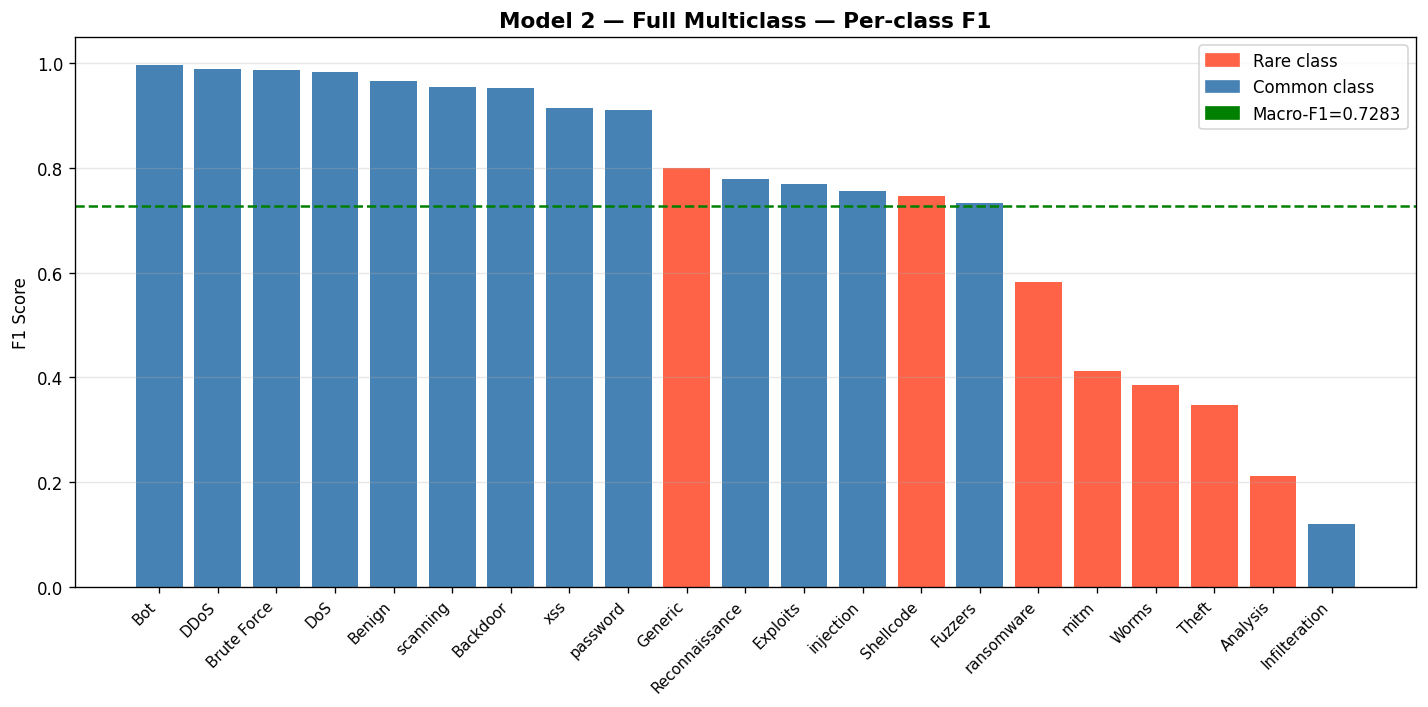

In [31]:
report   = classification_report(y_test_multi, preds_multi,
                                  target_names=le.classes_,
                                  output_dict=True, zero_division=0)
f1_vals  = {cls: report[cls]['f1-score'] for cls in le.classes_}
f1_df    = pd.DataFrame(list(f1_vals.items()), columns=['class', 'f1'])
f1_df    = f1_df.sort_values('f1', ascending=False)
macro_f1 = report['macro avg']['f1-score']

rare   = {'Worms','Shellcode','Analysis','Theft','ransomware','mitm','Generic'}
colors = ['tomato' if c in rare else 'steelblue' for c in f1_df['class']]

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.bar(f1_df['class'], f1_df['f1'], color=colors)
ax.axhline(macro_f1, color='green', linestyle='--',
           label=f'Macro-F1 = {macro_f1:.4f}')
ax.set_title('Model 2 — Full Multiclass — Per-class F1',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
patches = [mpatches.Patch(color='tomato',    label='Rare class'),
           mpatches.Patch(color='steelblue', label='Common class'),
           mpatches.Patch(color='green',     label=f'Macro-F1={macro_f1:.4f}')]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_per_class_f1.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class Precision_Recall heatmap

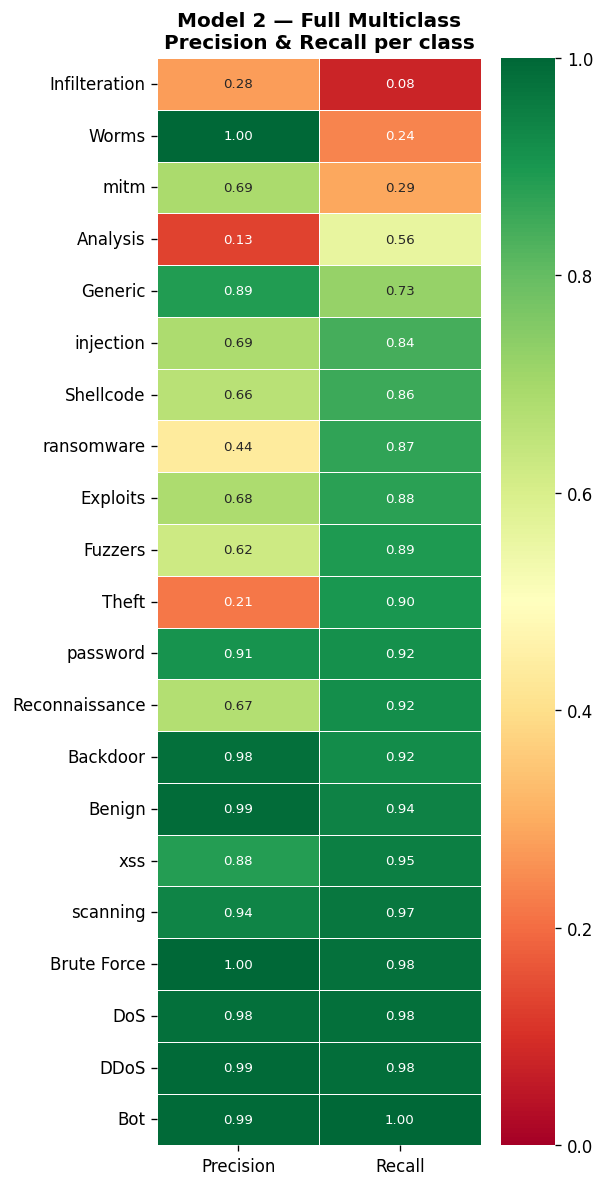

In [32]:
prec_vals = {cls: report[cls]['precision'] for cls in le.classes_}
rec_vals  = {cls: report[cls]['recall']    for cls in le.classes_}
pr_df     = pd.DataFrame({'Precision': prec_vals, 'Recall': rec_vals})
pr_df     = pr_df.sort_values('Recall', ascending=True)

fig, ax = plt.subplots(figsize=(5, 10), dpi=120)
sns.heatmap(pr_df, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Model 2 — Full Multiclass\nPrecision & Recall per class',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_precision_recall_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Feature Importance (TabNet attention masks)

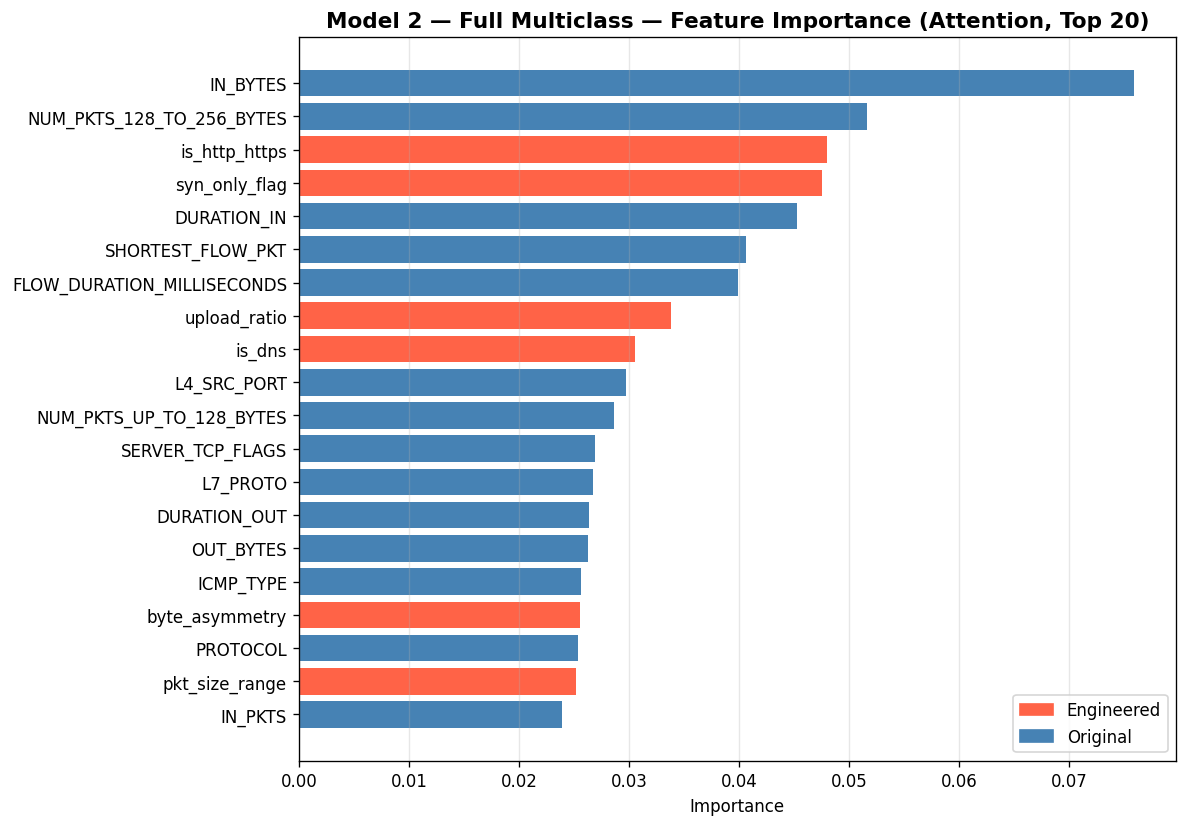

In [33]:
importance = tabnet_multi.feature_importances_
feat_df    = pd.DataFrame({'feature': mi_cols, 'importance': importance})
feat_df    = feat_df.sort_values('importance', ascending=False).head(20)
colors     = ['tomato' if f in engineered else 'steelblue'
               for f in feat_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_title('Model 2 — Full Multiclass — Feature Importance (Attention, Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
patches = [mpatches.Patch(color='tomato',    label='Engineered'),
           mpatches.Patch(color='steelblue', label='Original')]
ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [34]:
# Save preds to disk and free RAM
np.save(f'{models_dir}/preds_multi.npy', preds_multi)
del preds_multi
del tabnet_multi
if torch.cuda.is_available():
    torch.cuda.empty_cache()
del X_val
del y_val_bin, y_test_bin
del y_val_multi, y_test_multi
gc.collect()



2292

## Model 3 
## Attack-Only Multiclass 

In [35]:
# Load attack-only arrays 
X_train_att       = np.load(f'{artefacts_dir}/X_train_att.npy').astype(np.float32)
X_val_att         = np.load(f'{artefacts_dir}/X_val_att.npy').astype(np.float32)
X_test_att        = np.load(f'{artefacts_dir}/X_test_att.npy').astype(np.float32)
y_train_att_multi = np.load(f'{artefacts_dir}/y_train_att_multi.npy').astype(np.int64)
y_val_att_multi   = np.load(f'{artefacts_dir}/y_val_att_multi.npy').astype(np.int64)
y_test_att_multi  = np.load(f'{artefacts_dir}/y_test_att_multi.npy').astype(np.int64)

print(f'Train att : {X_train_att.shape}  dtype={X_train_att.dtype}')
print(f'Val att   : {X_val_att.shape}')
print(f'Test att  : {X_test_att.shape}')


Train att : (9213731, 42)  dtype=float32
Val att   : (3071244, 42)
Test att  : (3071244, 42)


In [36]:
ATT_CAPS = {
     5 : 1_200_000,   # DDoS
     6 : 1_200_000,   # DoS
    11 :   400_000,   # Reconnaissance
    17 :   200_000,   # password  
    19 :   400_000,   # scanning
    20 :   400_000,   # xss
    
}



In [37]:
rng_att = np.random.default_rng(42)
att_keep_idx = []
for cls_code in np.unique(y_train_att_multi):
    idx = np.where(y_train_att_multi == cls_code)[0]
    cap = ATT_CAPS.get(int(cls_code), len(idx))
    if len(idx) > cap:
        idx = rng_att.choice(idx, size=cap, replace=False)
    att_keep_idx.append(idx)

att_keep_idx = np.concatenate(att_keep_idx)
att_keep_idx.sort()

X_train_att       = X_train_att[att_keep_idx]
y_train_att_multi = y_train_att_multi[att_keep_idx]

In [38]:
print(f'Train att (subsampled) : {X_train_att.shape}')
print(f'Val att                : {X_val_att.shape}')
print(f'Test att               : {X_test_att.shape}')
print()
print('Train att class distribution after subsampling:')
unique_att, counts_att = np.unique(y_train_att_multi, return_counts=True)
for u, c in zip(unique_att, counts_att):
    print(f'  class {u:2d} : {c:>10,}')
print(f'  TOTAL   : {len(y_train_att_multi):>10,}')


Train att (subsampled) : (4011547, 42)
Val att                : (3071244, 42)
Test att               : (3071244, 42)

Train att class distribution after subsampling:
  class  0 :        227
  class  1 :      3,496
  class  3 :     11,759
  class  4 :     24,497
  class  5 :  1,200,000
  class  6 :  1,200,000
  class  7 :      5,951
  class  8 :      4,151
  class  9 :      1,933
  class 10 :     22,939
  class 11 :    400,000
  class 12 :        229
  class 13 :        422
  class 14 :         61
  class 15 :    133,775
  class 16 :      1,486
  class 17 :    200,000
  class 18 :        621
  class 19 :    400,000
  class 20 :    400,000
  TOTAL   :  4,011,547


In [39]:
from sklearn.preprocessing import LabelEncoder as LE
le_att = LE()
y_train_att_remap = le_att.fit_transform(y_train_att_multi)
y_val_att_remap   = le_att.transform(y_val_att_multi)
y_test_att_remap  = le_att.transform(y_test_att_multi)

attack_classes = [c for c in le.classes_ if c != 'Benign']
n_classes_att  = len(np.unique(y_train_att_remap))

# Remap weight dict keys from original le codes
log_smoothed_att_dict = {
    int(le_att.transform([orig_code])[0]): weight
    for orig_code, weight in log_smoothed_att_dict.items()
}

print(f'Attack classes : {n_classes_att}')

Attack classes : 20


In [40]:
tabnet_att = TabNetClassifier(**TABNET_PARAMS)

tabnet_att.fit(
    X_train_att, y_train_att_remap,
    eval_set    = [(X_val_att, y_val_att_remap)],
    eval_metric = ['accuracy', 'balanced_accuracy'],
    weights     = make_sample_weights(y_train_att_remap, log_smoothed_att_dict),
    **FIT_PARAMS
)

tabnet_att.save_model(f'{models_dir}/tabnet_att_multiclass')




epoch 0  | loss: 0.43149 | val_0_accuracy: 0.91214 | val_0_balanced_accuracy: 0.44788 |  0:00:31s
epoch 1  | loss: 0.19674 | val_0_accuracy: 0.95847 | val_0_balanced_accuracy: 0.67461 |  0:01:03s
epoch 2  | loss: 0.17805 | val_0_accuracy: 0.9706  | val_0_balanced_accuracy: 0.72905 |  0:01:35s
epoch 3  | loss: 0.18473 | val_0_accuracy: 0.9725  | val_0_balanced_accuracy: 0.74414 |  0:02:07s
epoch 4  | loss: 0.16241 | val_0_accuracy: 0.97326 | val_0_balanced_accuracy: 0.81372 |  0:02:39s
epoch 5  | loss: 0.16008 | val_0_accuracy: 0.9745  | val_0_balanced_accuracy: 0.78263 |  0:03:11s
epoch 6  | loss: 0.17186 | val_0_accuracy: 0.97394 | val_0_balanced_accuracy: 0.78282 |  0:03:44s
epoch 7  | loss: 0.15713 | val_0_accuracy: 0.97175 | val_0_balanced_accuracy: 0.76745 |  0:04:16s
epoch 8  | loss: 0.15931 | val_0_accuracy: 0.97357 | val_0_balanced_accuracy: 0.78901 |  0:04:49s
epoch 9  | loss: 0.15782 | val_0_accuracy: 0.97422 | val_0_balanced_accuracy: 0.78665 |  0:05:20s

Early stopping occu

'/kaggle/working/models_tabnet/tabnet_att_multiclass.zip'

In [41]:
# Free training data before prediction 
del X_train_att, y_train_att_remap
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


## Test model_3 performance on the test set

In [42]:
preds_att = evaluate(tabnet_att, X_test_att, y_test_att_remap,
                      label='Model 3 — Attack-Only Multiclass — Test Set',
                      class_names=attack_classes)


Model 3 — Attack-Only Multiclass — Test Set
Accuracy         : 0.9733
Macro-F1         : 0.7593
Weighted-F1      : 0.9739
                precision    recall  f1-score   support

      Analysis       0.12      0.61      0.20        75
      Backdoor       1.00      0.93      0.96      1165
           Bot       1.00      1.00      1.00      3920
   Brute Force       1.00      0.98      0.99      8165
          DDoS       0.99      0.98      0.99   1310954
           DoS       0.98      0.98      0.98   1088123
      Exploits       0.79      0.85      0.82      1984
       Fuzzers       0.67      0.92      0.78      1384
       Generic       0.84      0.69      0.76       645
 Infilteration       0.72      0.80      0.76      7646
Reconnaissance       0.94      0.93      0.94    166365
     Shellcode       0.55      0.95      0.69        76
         Theft       0.35      0.87      0.49       141
         Worms       0.00      0.00      0.00        21
     injection       0.66      0.83 

## Learning Curve

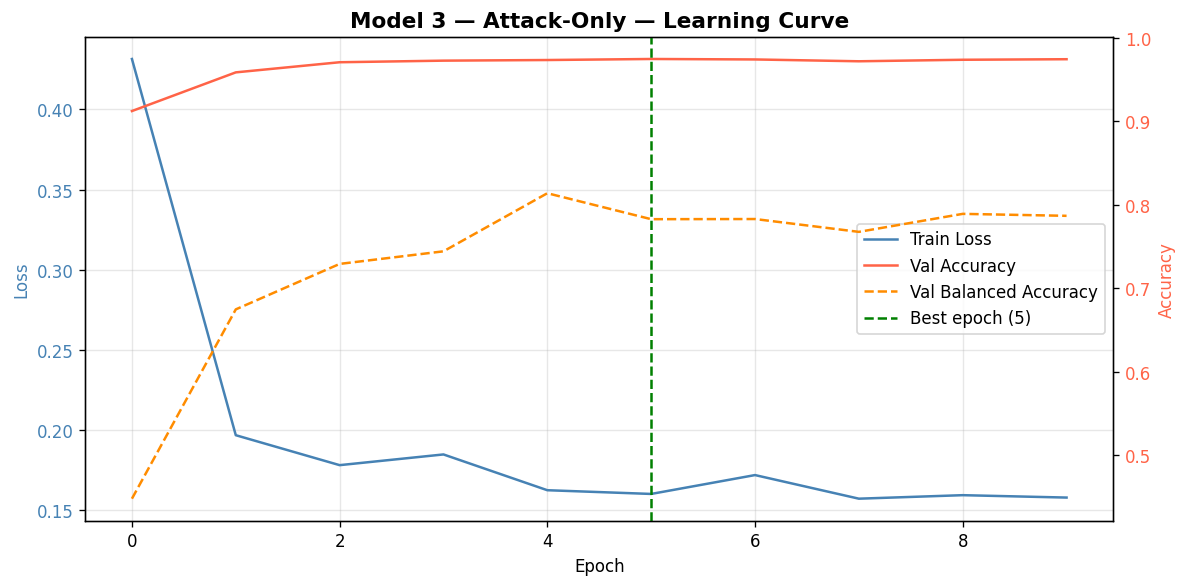

In [43]:
train_loss = tabnet_att.history['loss']
val_acc    = tabnet_att.history['val_0_accuracy']
val_bal    = tabnet_att.history['val_0_balanced_accuracy']
best_epoch = np.argmax(val_acc)

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=120)

ax1.plot(train_loss, label='Train Loss', color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(val_acc, label='Val Accuracy',          color='tomato')
ax2.plot(val_bal, label='Val Balanced Accuracy', color='darkorange', linestyle='--')
ax2.axvline(best_epoch, color='green', linestyle='--',
            label=f'Best epoch ({best_epoch})')
ax2.set_ylabel('Accuracy', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

ax1.set_title('Model 3 — Attack-Only — Learning Curve', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Confusion Matrix

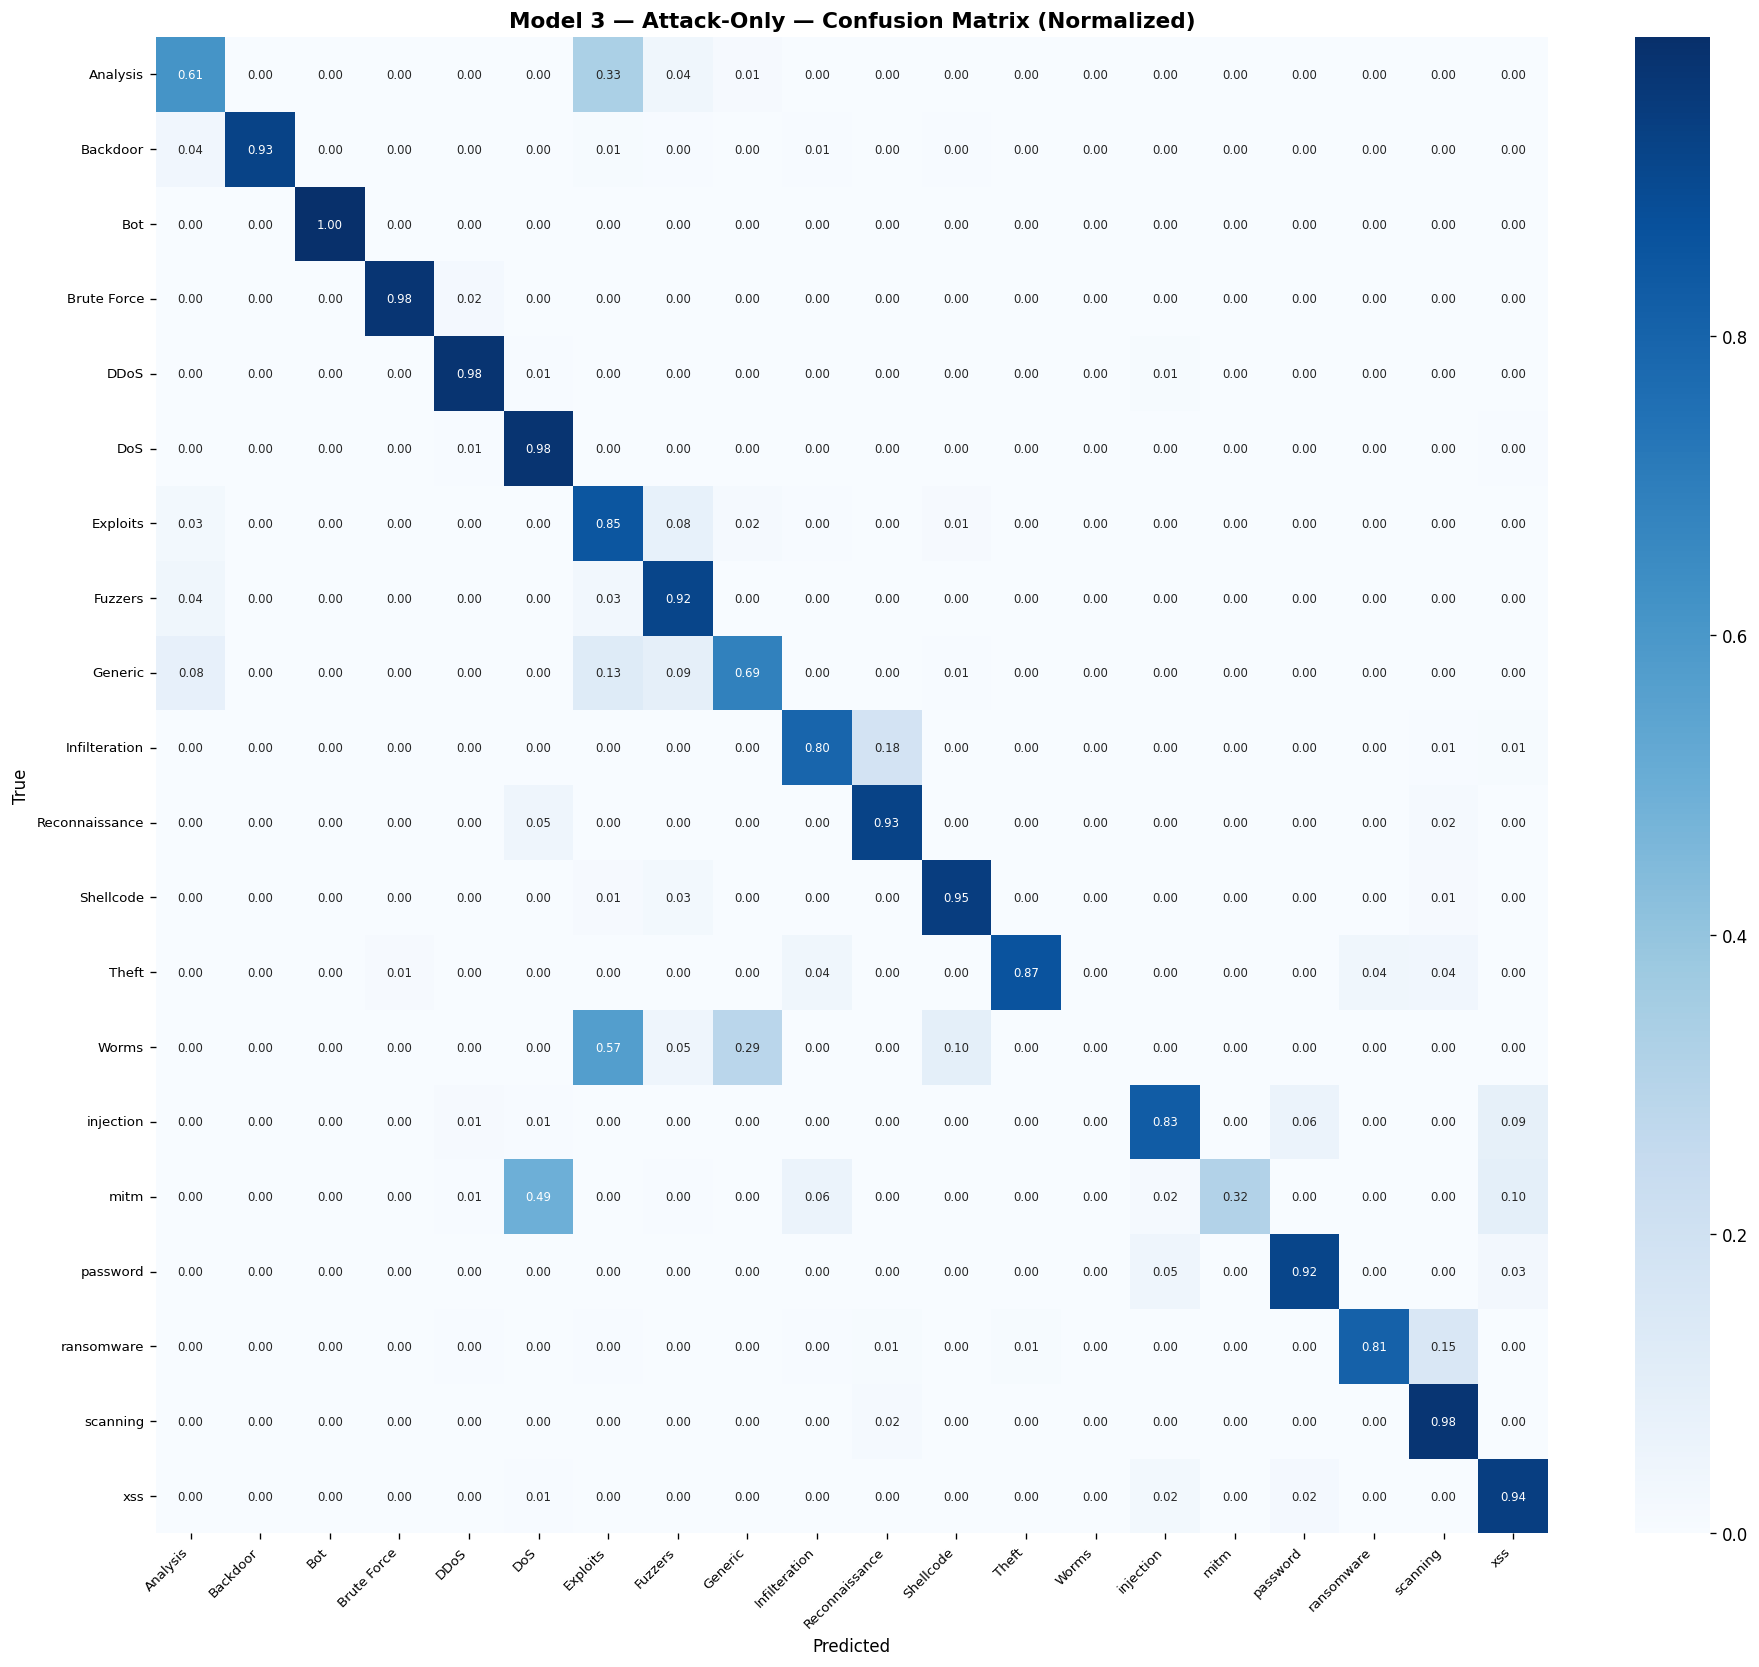

In [44]:
cm = confusion_matrix(y_test_att_remap, preds_att, normalize='true')
fig, ax = plt.subplots(figsize=(16, 14), dpi=120)
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=attack_classes,
            yticklabels=attack_classes, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Model 3 — Attack-Only — Confusion Matrix (Normalized)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class F1 bar chart

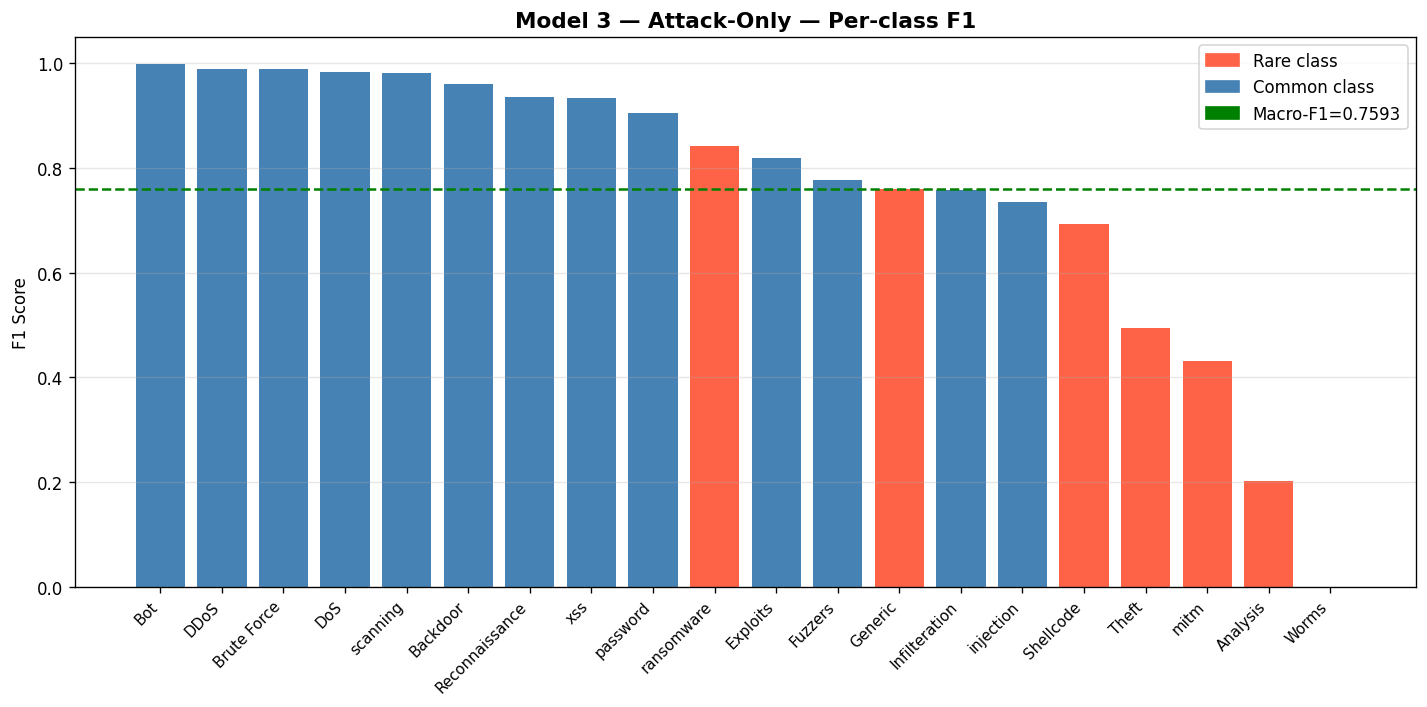

In [45]:
report_att = classification_report(y_test_att_remap, preds_att,
                                    target_names=attack_classes,
                                    output_dict=True, zero_division=0)
f1_vals_att  = {cls: report_att[cls]['f1-score'] for cls in attack_classes}
f1_df_att    = pd.DataFrame(list(f1_vals_att.items()), columns=['class', 'f1'])
f1_df_att    = f1_df_att.sort_values('f1', ascending=False)
macro_f1_att = report_att['macro avg']['f1-score']

rare   = {'Worms','Shellcode','Analysis','Theft','ransomware','mitm','Generic'}
colors = ['tomato' if c in rare else 'steelblue' for c in f1_df_att['class']]

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.bar(f1_df_att['class'], f1_df_att['f1'], color=colors)
ax.axhline(macro_f1_att, color='green', linestyle='--',
           label=f'Macro-F1 = {macro_f1_att:.4f}')
ax.set_title('Model 3 — Attack-Only — Per-class F1',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
patches = [mpatches.Patch(color='tomato',    label='Rare class'),
           mpatches.Patch(color='steelblue', label='Common class'),
           mpatches.Patch(color='green',     label=f'Macro-F1={macro_f1_att:.4f}')]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_per_class_f1.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class Precision_Recall heatmap

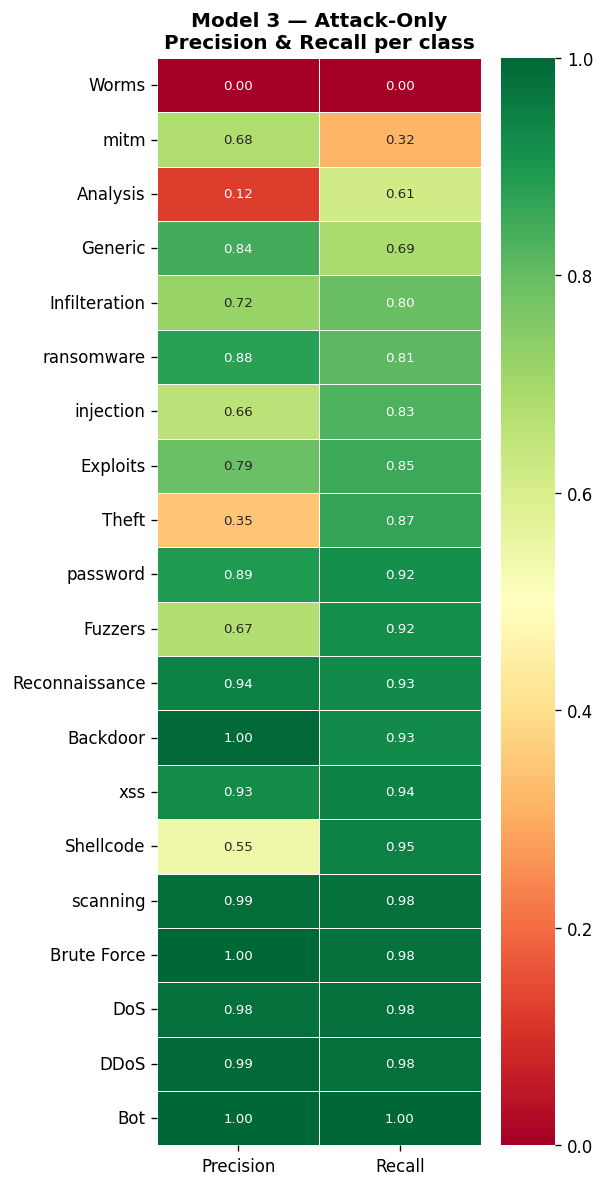

In [46]:
prec_vals_att = {cls: report_att[cls]['precision'] for cls in attack_classes}
rec_vals_att  = {cls: report_att[cls]['recall']    for cls in attack_classes}
pr_df_att     = pd.DataFrame({'Precision': prec_vals_att, 'Recall': rec_vals_att})
pr_df_att     = pr_df_att.sort_values('Recall', ascending=True)

fig, ax = plt.subplots(figsize=(5, 10), dpi=120)
sns.heatmap(pr_df_att, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Model 3 — Attack-Only\nPrecision & Recall per class',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_precision_recall_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Feature Importance

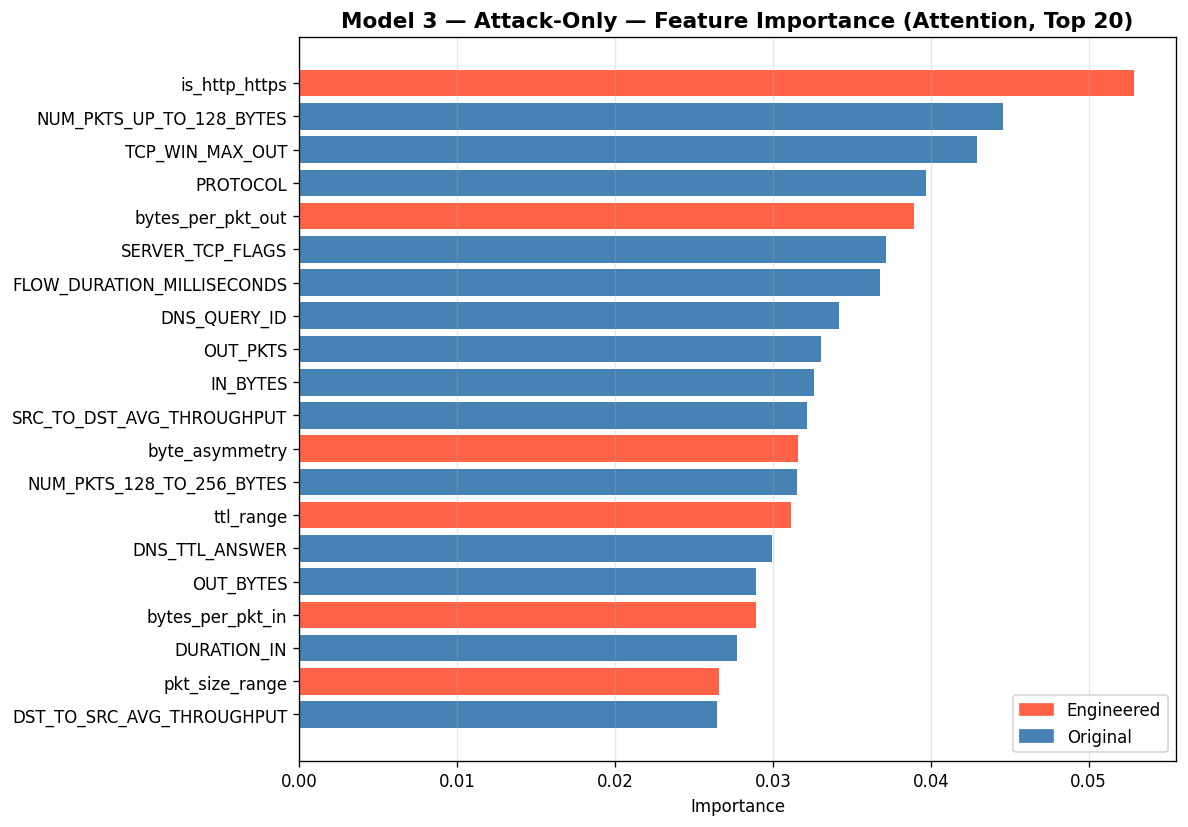

In [47]:
importance = tabnet_att.feature_importances_
feat_df    = pd.DataFrame({'feature': mi_cols, 'importance': importance})
feat_df    = feat_df.sort_values('importance', ascending=False).head(20)
colors     = ['tomato' if f in engineered else 'steelblue'
               for f in feat_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_title('Model 3 — Attack-Only — Feature Importance (Attention, Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
patches = [mpatches.Patch(color='tomato',    label='Engineered'),
           mpatches.Patch(color='steelblue', label='Original')]
ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [48]:
np.save(f'{models_dir}/preds_att.npy', preds_att)
del preds_att

del tabnet_att
del X_val_att
del y_train_att_multi, y_val_att_multi, y_val_att_remap
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()



51300

In [49]:
preds_bin   = np.load(f'{models_dir}/preds_bin.npy')
preds_multi = np.load(f'{models_dir}/preds_multi.npy')
preds_att   = np.load(f'{models_dir}/preds_att.npy')

## TabNet Unique — Attention Mask Visualization
per-sample feature selection — TabNet's key advantage over tree models

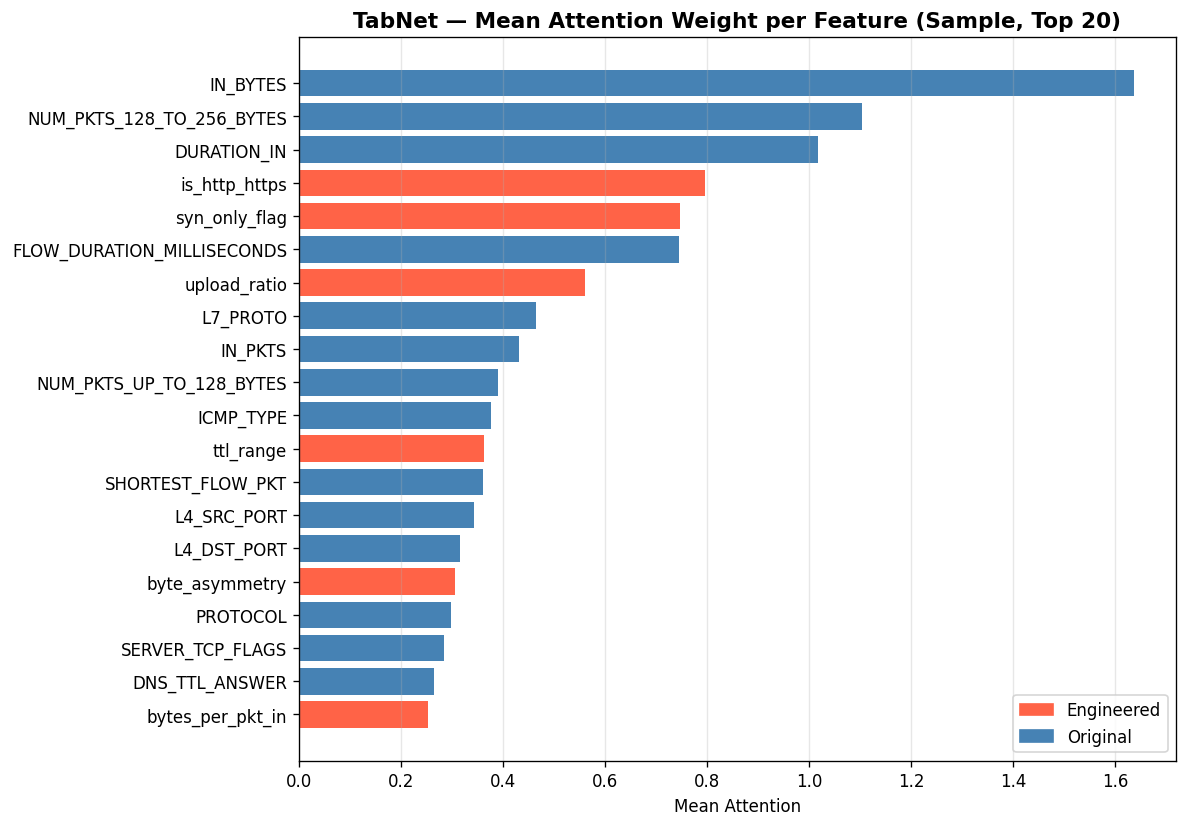

5509

In [50]:
tabnet_multi_reload = TabNetClassifier(**TABNET_PARAMS)
tabnet_multi_reload.load_model(f'{models_dir}/tabnet_multiclass.zip')


idx_s    = np.random.choice(len(X_test_att), size=2000, replace=False)
X_sample = X_test_att[idx_s]
y_sample = y_test_att_remap[idx_s]
explain_matrix, _ = tabnet_multi_reload.explain(X_sample)
mean_attention     = explain_matrix.mean(axis=0)

attn_df = pd.DataFrame({'feature': mi_cols, 'attention': mean_attention})
attn_df = attn_df.sort_values('attention', ascending=False).head(20)
colors  = ['tomato' if f in engineered else 'steelblue' for f in attn_df['feature']]



fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh(attn_df['feature'][::-1], attn_df['attention'][::-1], color=colors[::-1])
ax.set_title('TabNet — Mean Attention Weight per Feature (Sample, Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Attention')
patches = [mpatches.Patch(color='tomato',    label='Engineered'),
           mpatches.Patch(color='steelblue', label='Original')]

ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{plots_dir}/tabnet_attention_mean.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')
gc.collect()


##  Per_class attention heatmap — shows TabNet uses different features per attack type

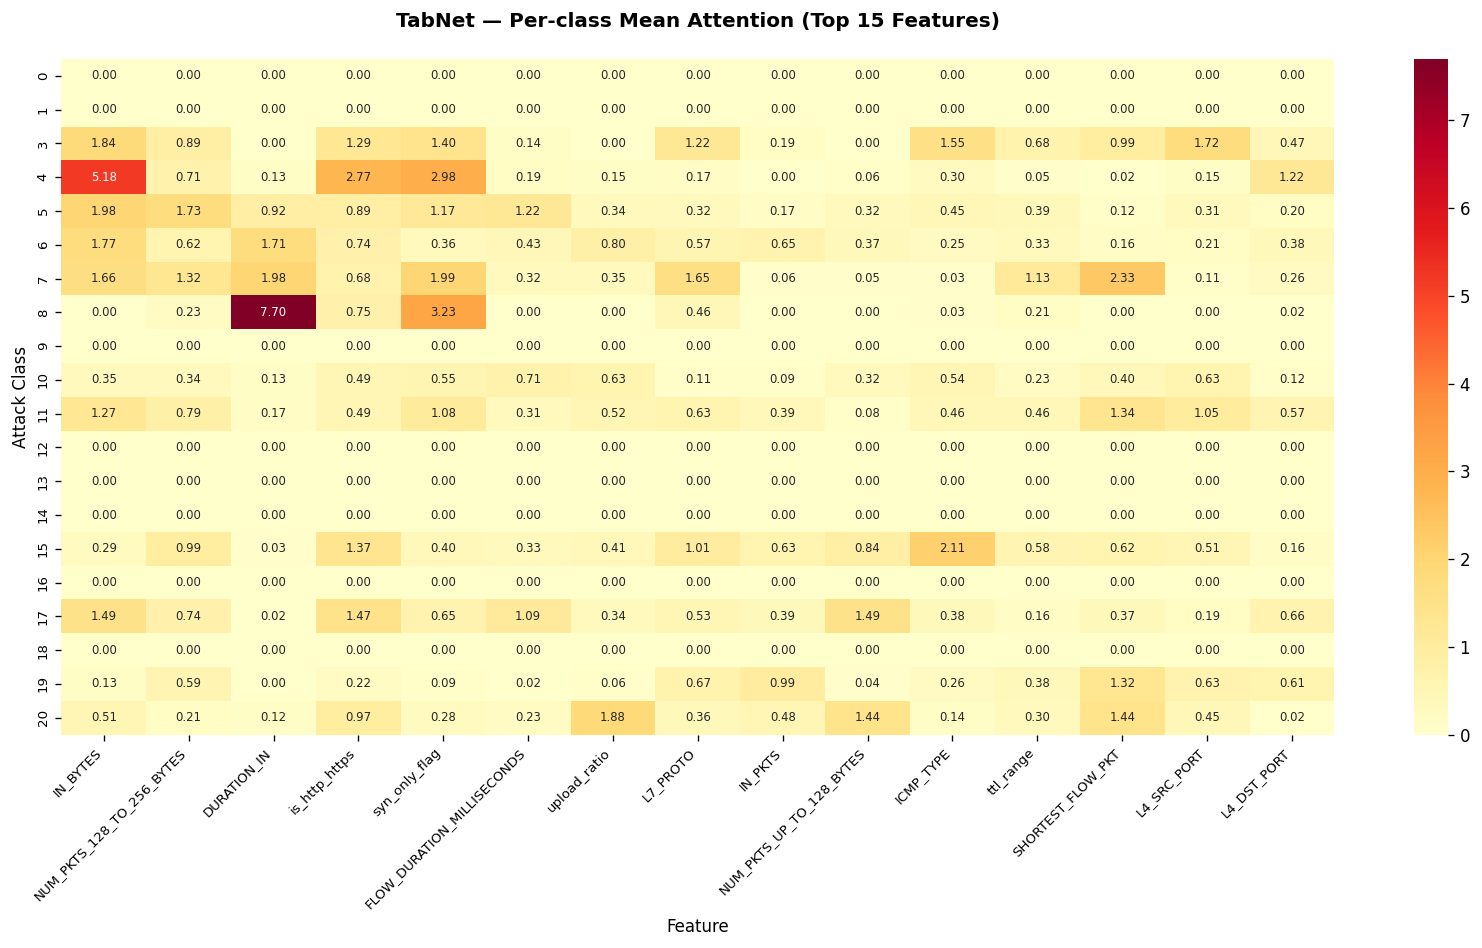

5807

In [51]:
top15_idx   = np.argsort(mean_attention)[::-1][:15]
top15_feats = [mi_cols[i] for i in top15_idx]


att_class_names = le_att.classes_   
n_att_classes   = len(att_class_names)
class_attn      = np.zeros((n_att_classes, 15))

for cls_idx in range(n_att_classes):
    mask = y_sample == cls_idx
    if mask.sum() > 0:
        class_attn[cls_idx] = explain_matrix[mask][:, top15_idx].mean(axis=0)

fig, ax = plt.subplots(figsize=(14, 8), dpi=120)

sns.heatmap(class_attn,
            xticklabels=top15_feats,
            yticklabels=att_class_names,
            cmap='YlOrRd', ax=ax,
            annot=True, fmt='.2f',
            annot_kws={'size': 7})
ax.set_title('TabNet — Per-class Mean Attention (Top 15 Features)\n',
             fontsize=12, fontweight='bold')


ax.set_xlabel('Feature')
ax.set_ylabel('Attack Class')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(f'{plots_dir}/tabnet_attention_per_class.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')
gc.collect()


In [52]:
del tabnet_multi_reload, explain_matrix, X_sample, y_sample, mean_attention
del preds_bin, preds_multi, preds_att
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

0

## Comparison between different papers done in the same dataset

In [53]:
papers = [
    "Sarhan\n2022",
    "Wijethilaka\n2025",
    "Mouatassim\n2024",
    "Bouzaachane\n2025",
    "Gu\n2024",
    "Krupski\n2024",
    "Komisarek\n2021",
    "Gouda\n2024",
    "Adeniyi\n2024",
    "TabNet\n MyModels"
]


In [54]:
# Binary
binary_scores = [
    0.9800,      # Sarhan ET Binary
    0.9480,      # Wijethilaka RF
    0.999939,    # Mouatassim XGB Binary
    1.0000,      # Bouzaachane RF Binary
    np.nan,      # Gu
    0.9530,      # Krupski DT 8feat
    0.9800,      # Komisarek RF
    0.9910,      # Gouda RF
    0.9890,      # Adeniyi AE-MLP
    0.9831       # TabNet Binary
]
# Full multiclass
multi_scores = [
    0.9700,      # Sarhan ET Multi
    0.8750,      # Wijethilaka LSTM
    0.9928,      # Mouatassim XGB Multi
    0.9900,      # Bouzaachane DBN Multi
    0.8900,      # Gu GNN
    0.9720,      # Krupski DT 30feat
    np.nan,
    np.nan,
    np.nan,
    0.9627       # TabNet Full Multi
]
# Attack-only multiclass
attack_only_scores = [
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    0.9739       # TabNet Attack-only
]


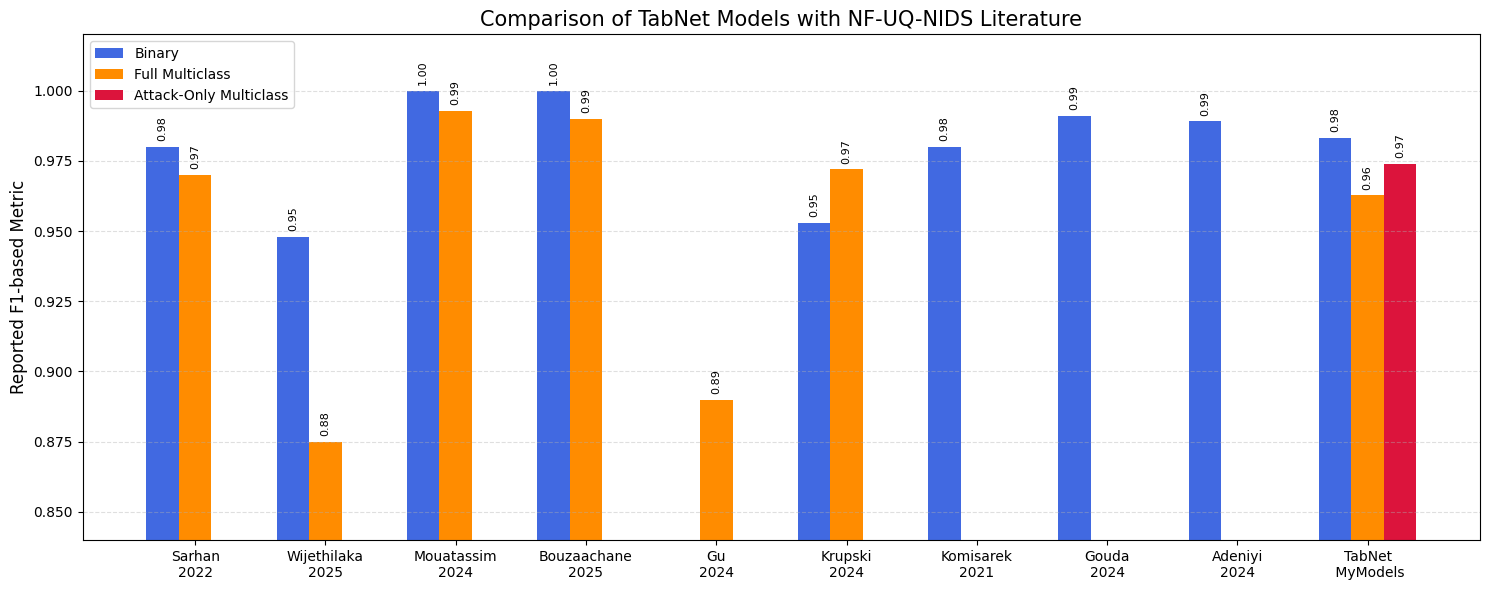

In [55]:
x = np.arange(len(papers))
width = 0.25
plt.figure(figsize=(15, 6))
bars1 = plt.bar(x - width,binary_scores,width,label='Binary',color='royalblue')
bars2 = plt.bar(x,multi_scores, width,label='Full Multiclass',color='darkorange')
bars3 = plt.bar(x + width,attack_only_scores,width,label='Attack-Only Multiclass',color='crimson')



for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()

        if not np.isnan(height):
            plt.text(bar.get_x() + bar.get_width()/2,height + 0.002,f"{height:.2f}", ha='center',va='bottom',fontsize=8, rotation=90 )


plt.xticks(x, papers, fontsize=10)
plt.ylabel("Reported F1-based Metric", fontsize=12)
plt.title("Comparison of TabNet Models with NF-UQ-NIDS Literature",fontsize=15)

plt.ylim(0.84, 1.02)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.legend()
plt.tight_layout()
plt.savefig(f'{plots_dir}/papers_Comparison.png', dpi=120, bbox_inches='tight')         
plt.show()

## Save models and artefacts

In [56]:
import os
import shutil
from IPython.display import display, FileLink

plots_dir = '/kaggle/working/plots_tabnet'
plots_zip = 'tabnet_plots.zip'

if os.path.exists(plots_dir):
 
    shutil.make_archive('tabnet_plots', 'zip', plots_dir)
    print(" TabNet Plots:")
    display(FileLink(plots_zip))
else:
    print(f" Directory not found: {plots_dir}")







 TabNet Plots:


/kaggle/working/tabnet_plots.zip

In [57]:
models_dir = '/kaggle/working/models_tabnet'
models_zip = 'tabnet_models.zip'

if os.path.exists(models_dir):
    
    shutil.make_archive('tabnet_models', 'zip', models_dir)
    print(" TabNet Models:")
    display(FileLink(models_zip))
else:
    print(f" Directory not found: {models_dir}")

 TabNet Models:


/kaggle/working/tabnet_models.zip